In [11]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import swin_t, Swin_T_Weights
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [13]:
class PatchDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        self.label_map = {
            "normal": 0,
            "hcc": 1,
            "chol": 1
        }

        for cls in ["normal", "hcc", "chol"]:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue

            for slide_id in os.listdir(cls_dir):
                slide_path = os.path.join(cls_dir, slide_id)

                if not os.path.isdir(slide_path):
                    continue

                for fname in os.listdir(slide_path):
                    if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                        self.samples.append(
                            (os.path.join(slide_path, fname),
                             self.label_map[cls])
                        )

        print(f"Loaded {len(self.samples)} patches from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)


In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [16]:
train_dataset = PatchDataset("TRAIN", transform=train_transform)
test_dataset  = PatchDataset("TEST", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


Loaded 111300 patches from TRAIN
Loaded 28000 patches from TEST


In [6]:
model = swin_t(weights=Swin_T_Weights.DEFAULT)

# Replace classifier head
model.head = nn.Linear(model.head.in_features, 2)

model = model.to(device)


/home/jupyter-238w1a05a8/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [7]:
class_weights = torch.tensor([1.5, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [8]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


In [9]:
def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


In [12]:
EPOCHS = 10

for epoch in range(EPOCHS):
    loss, acc = train_epoch(model, train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")


Epoch 1/10 | Loss: 0.0086 | Train Acc: 0.9971
Epoch 2/10 | Loss: 0.0035 | Train Acc: 0.9990
Epoch 3/10 | Loss: 0.0033 | Train Acc: 0.9990
Epoch 4/10 | Loss: 0.0024 | Train Acc: 0.9992
Epoch 5/10 | Loss: 0.0029 | Train Acc: 0.9991
Epoch 6/10 | Loss: 0.0025 | Train Acc: 0.9991
Epoch 7/10 | Loss: 0.0020 | Train Acc: 0.9994
Epoch 8/10 | Loss: 0.0020 | Train Acc: 0.9994
Epoch 9/10 | Loss: 0.0019 | Train Acc: 0.9994
Epoch 10/10 | Loss: 0.0018 | Train Acc: 0.9994


In [13]:
y_true, y_pred = evaluate(model, test_loader)

print("Patch-Level Test Accuracy:",
      accuracy_score(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true, y_pred,
    target_names=["Normal", "Cancer"],
    digits=4
))


Patch-Level Test Accuracy: 0.9734432234432234
[[13275    25]
 [  700 13300]]
              precision    recall  f1-score   support

      Normal     0.9499    0.9981    0.9734     13300
      Cancer     0.9981    0.9500    0.9735     14000

    accuracy                         0.9734     27300
   macro avg     0.9740    0.9741    0.9734     27300
weighted avg     0.9746    0.9734    0.9734     27300



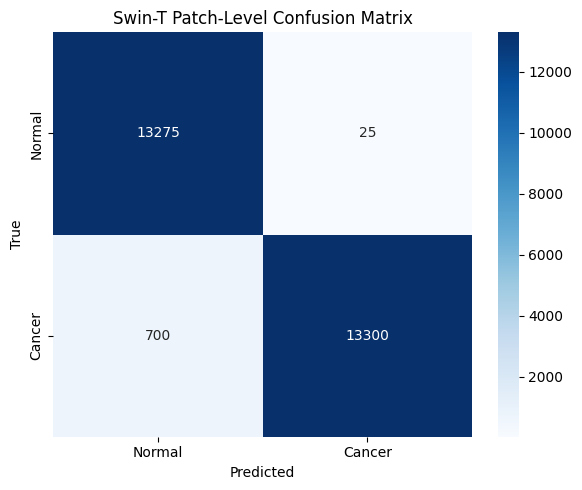

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Cancer"],
    yticklabels=["Normal", "Cancer"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Swin-T Patch-Level Confusion Matrix")
plt.tight_layout()
plt.show()


In [17]:
import torch.nn.functional as F
import numpy as np
import os
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_slide_level_modelA(model, root_dir, transform, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for cls in ["normal", "hcc", "chol"]:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue

            for slide_id in os.listdir(cls_dir):
                slide_path = os.path.join(cls_dir, slide_id)

                patch_probs = []

                for fname in os.listdir(slide_path):
                    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                        continue

                    img = Image.open(os.path.join(slide_path, fname)).convert("RGB")
                    img = transform(img).unsqueeze(0).to(device)

                    output = model(img)
                    prob = F.softmax(output, dim=1)[0][1].item()  # cancer prob
                    patch_probs.append(prob)

                if len(patch_probs) == 0:
                    continue

                avg_prob = np.mean(patch_probs)

                true_label = 0 if cls == "normal" else 1
                pred_label = 1 if avg_prob > 0.5 else 0

                y_true.append(true_label)
                y_pred.append(pred_label)

    return y_true, y_pred


In [32]:
y_true_A, y_pred_A = evaluate_slide_level_modelA(
    model,
    "TEST",
    test_transform,
    device
)

print("Model-A Slide-Level Accuracy:",
      accuracy_score(y_true_A, y_pred_A))

print(confusion_matrix(y_true_A, y_pred_A))

print(classification_report(
    y_true_A,
    y_pred_A,
    target_names=["Normal", "Cancer"],
    digits=4
))


Model-A Slide-Level Accuracy: 0.94
[[23  2]
 [ 1 24]]
              precision    recall  f1-score   support

      Normal     0.9583    0.9200    0.9388        25
      Cancer     0.9231    0.9600    0.9412        25

    accuracy                         0.9400        50
   macro avg     0.9407    0.9400    0.9400        50
weighted avg     0.9407    0.9400    0.9400        50



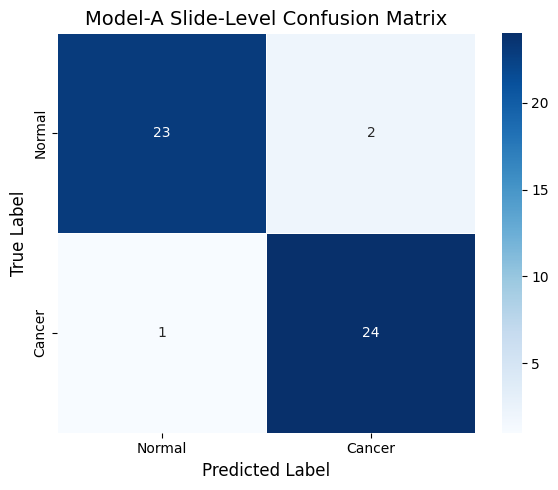

In [33]:
cm_A = confusion_matrix(y_true_A, y_pred_A)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_A,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Cancer"],
    yticklabels=["Normal", "Cancer"],
    linewidths=0.5
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Model-A Slide-Level Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [34]:
torch.save(model.state_dict(), "model_finalA_patch_swin.pth")
print("Model-A (patch CNN) saved successfully.")


Model-A (patch CNN) saved successfully.


In [2]:
import torch
import torch.nn as nn
from torchvision.models import swin_t
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "model_finalA_patch_swin.pth"   # change path

modelA = swin_t(weights=None)
modelA.head = nn.Linear(modelA.head.in_features, 2)

modelA.load_state_dict(torch.load(MODEL_PATH, map_location=device))
modelA.to(device)
modelA.eval()

print("Model loaded successfully")


/home/jupyter-238w1a05a8/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Model loaded successfully


In [17]:
from sklearn.metrics import accuracy_score

def evaluate_modelA_full(model, loader, device):

    model.eval()
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)

            cancer_prob = probs[:,1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(cancer_prob)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [18]:
y_true, y_pred, y_prob = evaluate_modelA_full(
    modelA,
    test_loader,   # your test loader
    device
)


In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal","Cancer"],
    digits=4
))


              precision    recall  f1-score   support

      Normal     1.0000    0.9482    0.9734     14000
      Cancer     0.9508    1.0000    0.9748     14000

    accuracy                         0.9741     28000
   macro avg     0.9754    0.9741    0.9741     28000
weighted avg     0.9754    0.9741    0.9741     28000



In [21]:
import numpy as np
from sklearn.metrics import accuracy_score

def accuracy_confidence_interval(y_true, y_pred, confidence=0.95):
    acc = accuracy_score(y_true, y_pred)
    n = len(y_true)

    z = 1.96  # for 95%
    se = np.sqrt((acc * (1 - acc)) / n)

    lower = acc - z * se
    upper = acc + z * se

    return acc, lower, upper

In [22]:
acc, low, high = accuracy_confidence_interval(y_true, y_pred)

print(f"Model-A Accuracy: {acc:.4f}")
print(f"95% CI: [{low:.4f}, {high:.4f}]")

Model-A Accuracy: 0.9741
95% CI: [0.9722, 0.9760]


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

def print_metrics(y_true, y_pred, name):
    print(f"\n{name} Metrics")
    print("Precision:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall:", recall_score(y_true, y_pred, average="weighted"))
    print("F1 Score:", f1_score(y_true, y_pred, average="weighted"))


In [24]:
print_metrics(y_true, y_pred, "Model-A")


Model-A Metrics
Precision: 0.9753820033955858
Recall: 0.9741071428571428
F1 Score: 0.9740897716022939


In [25]:
from sklearn.utils import resample

def bootstrap_accuracy(y_true, y_pred, n_bootstrap=1000):

    scores = []

    for _ in range(n_bootstrap):
        y_t, y_p = resample(y_true, y_pred)
        scores.append(accuracy_score(y_t, y_p))

    scores = np.array(scores)

    mean = scores.mean()
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean, lower, upper



In [26]:
mean, low, high = bootstrap_accuracy(y_true, y_pred)
print("Model-A Bootstrap Accuracy:", mean)
print("95% CI:", low, high)


Model-A Bootstrap Accuracy: 0.9741593214285715
95% CI: 0.9723205357142857 0.9758571428571429


In [30]:
def evaluate_modelB_with_probs(modelA, loader, device):

    modelA.eval()
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)

            outputs = modelA(imgs)
            probs = torch.softmax(outputs, dim=1)

            # CHOL probability
            chol_prob = probs[:,1].cpu().numpy()

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(chol_prob)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [31]:
y_true_A, y_pred_A, y_prob_A = evaluate_modelB_with_probs(
    modelA,
    test_loader,
    device
)


In [32]:
from sklearn.metrics import roc_auc_score

roc_auc_A = roc_auc_score(y_true, y_prob)
print("Model-A ROC-AUC:", roc_auc_A)

Model-A ROC-AUC: 0.9759773724489796


In [34]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_true, y_pred)
print("Cohen Kappa Score:", kappa)


Cohen Kappa Score: 0.9482142857142857


In [36]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()


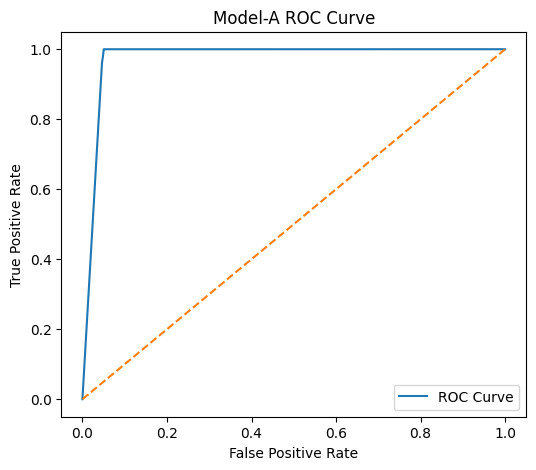

In [38]:
plot_roc_curve(y_true, y_prob, "Model-A ROC Curve")